In [19]:
#imports

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as patches

In [20]:
#load t3pa file

folder = r"G:\Shared drives\XPCS_2026\data\FCGT_12-15-24\TimePix3"

# change this filename to analyze a different temperature
filename = "255K_1800s.t3pa"

filepath = os.path.join(folder, filename)

data = np.loadtxt(filepath, skiprows=1)

ids = data[:, 0].astype(np.int64)
times_ns = data[:, 1]

print(f"Loaded {len(ids):,} events")

Loaded 30,023,659 events


In [3]:
#decode pixel ids

x = ids % 512
y = ids // 512

print("Detector size: 512 x 512")

Detector size: 512 x 512


In [4]:
#make detector image

image = np.zeros((512, 512))

for xx, yy in zip(x, y):
    image[yy, xx] += 1

print("Total counts:", image.sum())

Total counts: 30023659.0


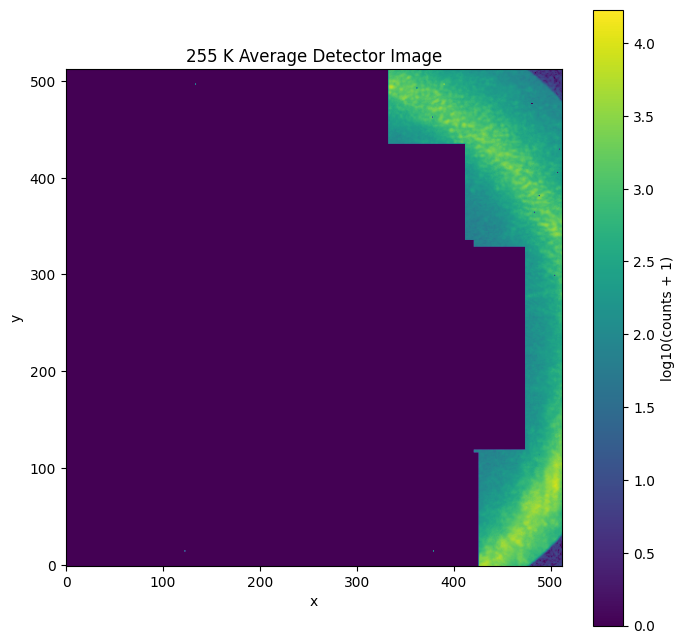

In [5]:
#show detector image

plt.figure(figsize=(8, 8))

plt.imshow(
    np.log10(image + 1),
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="log10(counts + 1)")

plt.xlabel("x")
plt.ylabel("y")

plt.title("255 K Average Detector Image")

plt.show()

In [8]:
#pick roi locations

roi_top = {
    "x0": 400,
    "y0": 400,
    "width": 80,
    "height": 100
}

roi_bottom = {
    "x0": 420,
    "y0": 0,
    "width": 100,
    "height": 80
}

roi_large = {
    "x0": 400,
    "y0": 10,
    "width": 100,
    "height": 450
}

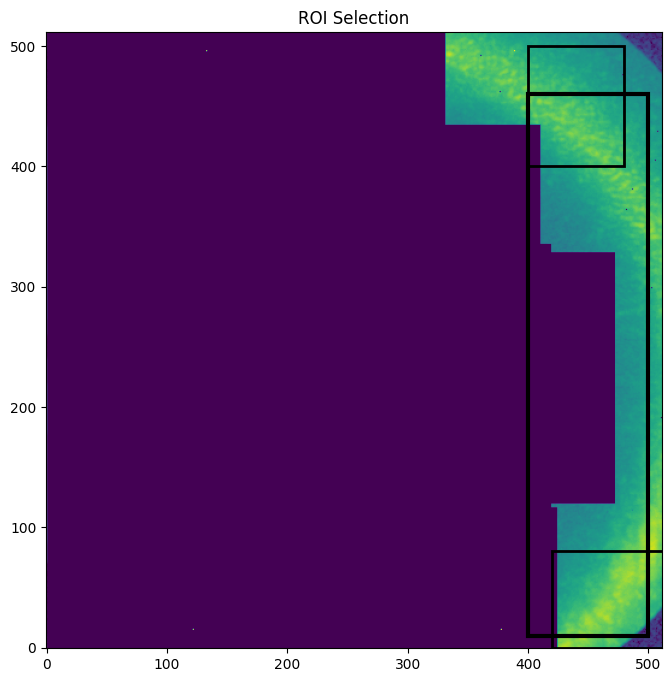

In [9]:
#draw rois

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    np.log10(image + 1),
    origin="lower",
    cmap="viridis"
)

rect1 = Rectangle(
    (roi_top["x0"], roi_top["y0"]),
    roi_top["width"],
    roi_top["height"],
    fill=False,
    linewidth=2
)

rect2 = Rectangle(
    (roi_bottom["x0"], roi_bottom["y0"]),
    roi_bottom["width"],
    roi_bottom["height"],
    fill=False,
    linewidth=2
)

rect3 = Rectangle(
    (roi_large["x0"], roi_large["y0"]),
    roi_large["width"],
    roi_large["height"],
    fill=False,
    linewidth=3
)

ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)

plt.title("ROI Selection")

plt.show()

In [14]:
#create time bins

bin_width_ns = 1e9

start_time = times_ns.min()
end_time = times_ns.max()

bin_edges = np.arange(
    start_time,
    end_time + bin_width_ns,
    bin_width_ns
)

n_bins = len(bin_edges) - 1

print("Number of bins:", n_bins)

Number of bins: 5


In [15]:
#build roi masks

top_mask = (
    (x >= roi_top["x0"]) &
    (x < roi_top["x0"] + roi_top["width"]) &
    (y >= roi_top["y0"]) &
    (y < roi_top["y0"] + roi_top["height"])
)

bottom_mask = (
    (x >= roi_bottom["x0"]) &
    (x < roi_bottom["x0"] + roi_bottom["width"]) &
    (y >= roi_bottom["y0"]) &
    (y < roi_bottom["y0"] + roi_bottom["height"])
)

large_mask = (
    (x >= roi_large["x0"]) &
    (x < roi_large["x0"] + roi_large["width"]) &
    (y >= roi_large["y0"]) &
    (y < roi_large["y0"] + roi_large["height"])
)

In [16]:
#roi intensity traces

top_trace = []
bottom_trace = []
large_trace = []

for i in range(n_bins):

    t0 = bin_edges[i]
    t1 = bin_edges[i + 1]

    time_mask = (times_ns >= t0) & (times_ns < t1)

    top_trace.append(
        np.sum(time_mask & top_mask)
    )

    bottom_trace.append(
        np.sum(time_mask & bottom_mask)
    )

    large_trace.append(
        np.sum(time_mask & large_mask)
    )

top_trace = np.array(top_trace)
bottom_trace = np.array(bottom_trace)
large_trace = np.array(large_trace)

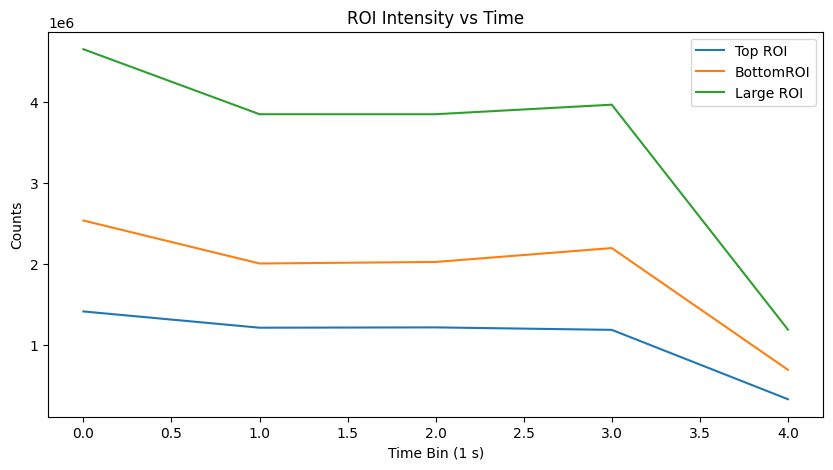

In [18]:
#plot roi intensities

time_axis = np.arange(n_bins)

plt.figure(figsize=(10, 5))

plt.plot(time_axis, top_trace, label="Top ROI")
plt.plot(time_axis, bottom_trace, label="Bottom ROI")
plt.plot(time_axis, large_trace, label="Large ROI")

plt.xlabel("Time Bin (1 s)")
plt.ylabel("Counts")

plt.legend()

plt.title("ROI Intensity vs Time")

plt.show()